# 3. Análises — Brink Calçados
**Fonte:** Receita Federal do Brasil — Declarações de Importação (Out–Dez 2025)

Parte do CSV refined (somente calçados, colunas selecionadas) e gera as visualizações em `analyses/`.

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 3. Preparação para os gráficos

Agregamos os dados por país de origem e criamos as métricas derivadas que serão usadas nas visualizações.

In [2]:
NOTA_CONTEXTO = (
    'Fonte: Receita Federal do Brasil — Declarações de Importação (Out-Dez 2025).\n'
    'Preço FOB = valor médio por par declarado na saída do país de origem, sem impostos brasileiros.\n'
    'Diferenças de preço entre países refletem o tipo de calçado importado (ex: couro italiano vs. sintético asiático).'
)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

PALETA = [
    '#E63946', '#F4A261', '#457B9D', '#2A9D8F',
    '#E9C46A', '#6D6875', '#B5838D', '#80B918',
    '#A8DADC', '#CDB4DB', '#FFAFCC', '#ADB5BD',
]

NOMES = {
    'CHINA, REPUBLICA POPULAR': 'China',
    'VIETNA': 'Vietnã',
    'INDONESIA': 'Indonésia',
    'ITALIA': 'Itália',
    'CAMBOJA': 'Camboja',
    'PARAGUAI': 'Paraguai',
    'ALEMANHA': 'Alemanha',
    'ESPANHA': 'Espanha',
    'PORTUGAL': 'Portugal',
    'INDIA': 'Índia',
    'COLOMBIA': 'Colômbia',
    'HONG KONG': 'Hong Kong',
}

df = pd.read_csv('refined/estatisticas_di_2025_10-12_refined.csv')

by_country = df.groupby('pais_origem').agg(
    preco_medio=('preco_medio', 'mean'),
    frete_medio=('frete_medio', 'mean'),
    seguro_medio=('seguro_medio', 'mean'),
    valor_total=('valor_total', 'sum'),
    volume_total=('volume_total', 'sum'),
).reset_index()

by_country['custo_chegada'] = (
    by_country['preco_medio'] +
    by_country['frete_medio'] +
    by_country['seguro_medio']
)
by_country['overhead_pct'] = (
    (by_country['frete_medio'] + by_country['seguro_medio'])
    / by_country['preco_medio'] * 100
).round(1)

by_country['pais_label'] = by_country['pais_origem'].map(NOMES)

def adicionar_nota(fig):
    fig.text(
        0.01, -0.04, NOTA_CONTEXTO,
        fontsize=8, color='#555555', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0F4FF', alpha=0.8, edgecolor='#AABBDD')
    )

print('✔ Dados agregados por país — prontos para visualização')
by_country[['pais_label', 'preco_medio', 'frete_medio', 'volume_total']]

✔ Dados agregados por país — prontos para visualização


,pais_label,preco_medio,frete_medio,volume_total
0,Alemanha,83.950000,5.490000,9964.0
1,Camboja,24.760000,446.800000,192870.0
2,China,32.307222,732.727778,3420590.0
3,Colômbia,8.660000,1030.000000,17400.0
4,Espanha,128.525000,319.050000,7277.0
5,Hong Kong,44.300000,267.000000,20400.0
6,Índia,32.000000,75.200000,15400.0
7,Indonésia,21.925000,408.500000,1817000.0
8,Itália,327.107692,113.500000,51154.0
9,Paraguai,1.210000,368.000000,1400000.0


## 4. Gráfico 1 — Qual país vende o calçado mais barato?

Ranking de preço médio FOB por par, do mais barato ao mais caro. A linha pontilhada indica a mediana dos preços.

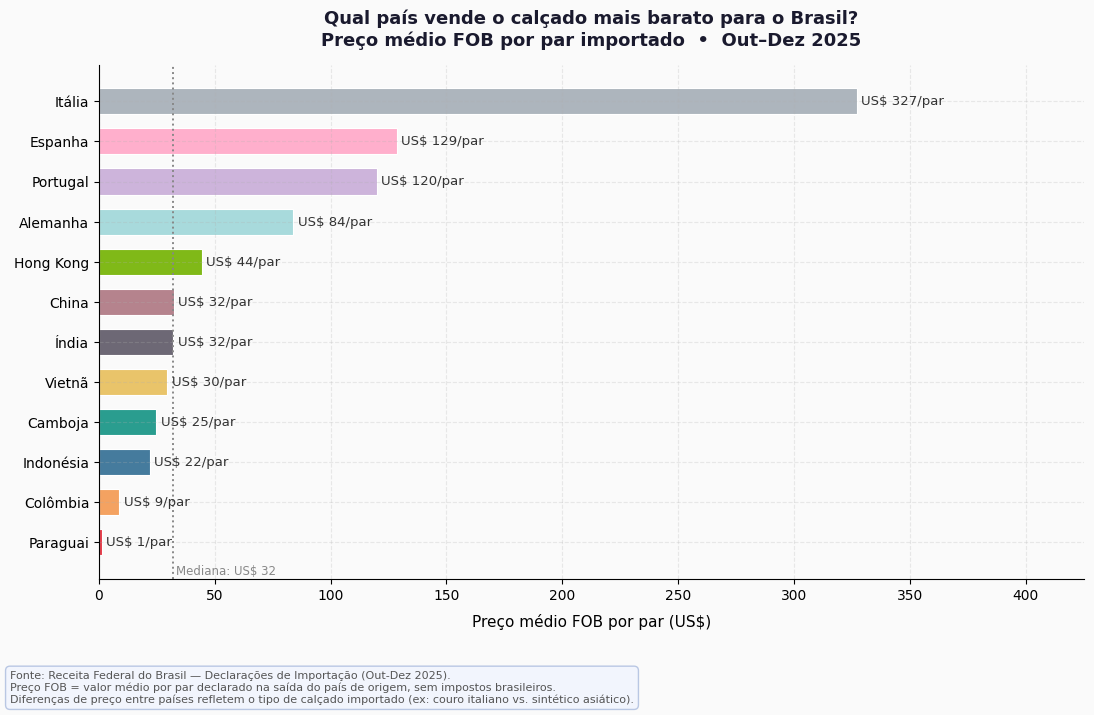

In [3]:
df1 = by_country.sort_values('preco_medio', ascending=True).reset_index(drop=True)

fig1, ax1 = plt.subplots(figsize=(11, 6.5))
fig1.patch.set_facecolor('#FAFAFA')
ax1.set_facecolor('#FAFAFA')

bars1 = ax1.barh(df1['pais_label'], df1['preco_medio'],
                 color=PALETA[:len(df1)], edgecolor='white', linewidth=0.8, height=0.65)

for bar, val in zip(bars1, df1['preco_medio']):
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
             f'US$ {val:,.0f}/par', va='center', ha='left', fontsize=9.5, color='#333')

mediana = df1['preco_medio'].median()
ax1.axvline(mediana, color='#888', linestyle=':', linewidth=1.4)
ax1.text(mediana + 1, -0.8, f'Mediana: US$ {mediana:.0f}', fontsize=8.5, color='#888')

ax1.set_xlabel('Preço médio FOB por par (US$)', labelpad=8)
ax1.set_xlim(0, df1['preco_medio'].max() * 1.30)
ax1.set_title(
    'Qual país vende o calçado mais barato para o Brasil?\n'
    'Preço médio FOB por par importado  •  Out–Dez 2025',
    fontsize=13, fontweight='bold', pad=14, color='#1a1a2e'
)
adicionar_nota(fig1)
fig1.tight_layout()
fig1.savefig('analyses/g1_preco_por_pais.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Gráfico 2 — Qual país tem o frete mais caro?

Ranking de frete médio por embarque. Importante cruzar com o gráfico anterior — um país pode ter calçado barato mas frete caro, impactando o custo final.

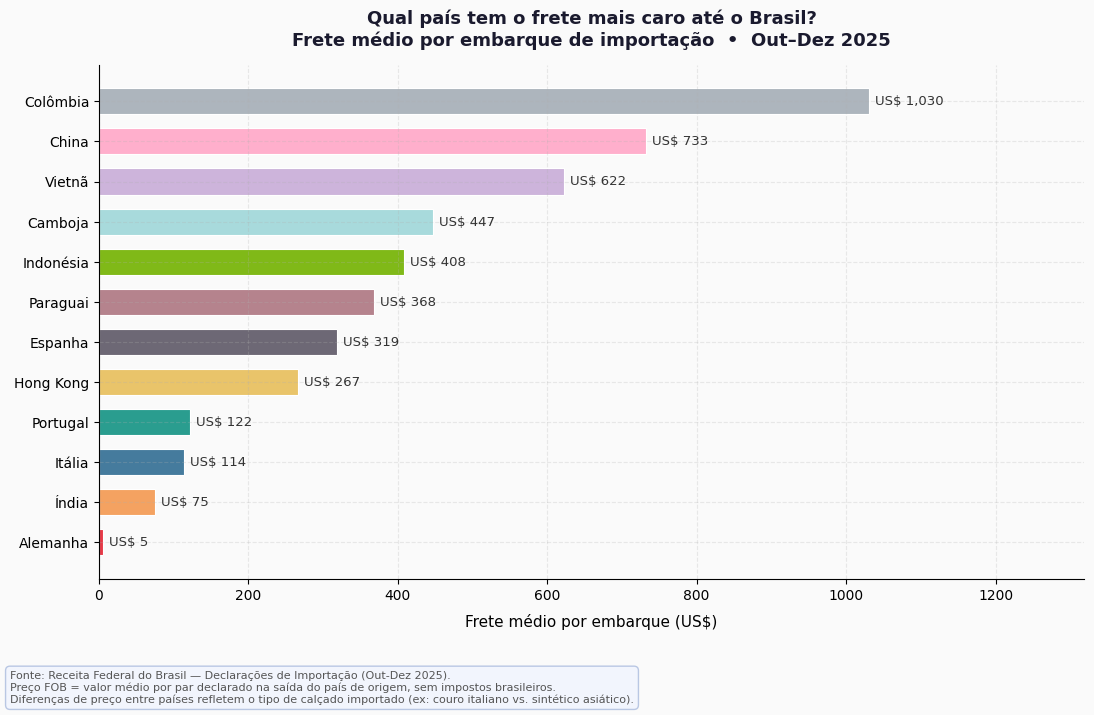

In [4]:
df2 = by_country.sort_values('frete_medio', ascending=True).reset_index(drop=True)

fig2, ax2 = plt.subplots(figsize=(11, 6.5))
fig2.patch.set_facecolor('#FAFAFA')
ax2.set_facecolor('#FAFAFA')

bars2 = ax2.barh(df2['pais_label'], df2['frete_medio'],
                 color=PALETA[:len(df2)], edgecolor='white', linewidth=0.8, height=0.65)

for bar, val in zip(bars2, df2['frete_medio']):
    ax2.text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
             f'US$ {val:,.0f}', va='center', ha='left', fontsize=9.5, color='#333')

ax2.set_xlabel('Frete médio por embarque (US$)', labelpad=8)
ax2.set_xlim(0, df2['frete_medio'].max() * 1.28)
ax2.set_title(
    'Qual país tem o frete mais caro até o Brasil?\n'
    'Frete médio por embarque de importação  •  Out–Dez 2025',
    fontsize=13, fontweight='bold', pad=14, color='#1a1a2e'
)
adicionar_nota(fig2)
fig2.tight_layout()
fig2.savefig('analyses/g2_frete_por_pais.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Gráfico 3 — Preço vs Frete por país

Gráfico de bolhas que combina preço FOB e custo de frete. Os quadrantes ajudam a identificar o melhor custo total. O tamanho da bolha representa o volume total de pares importados.

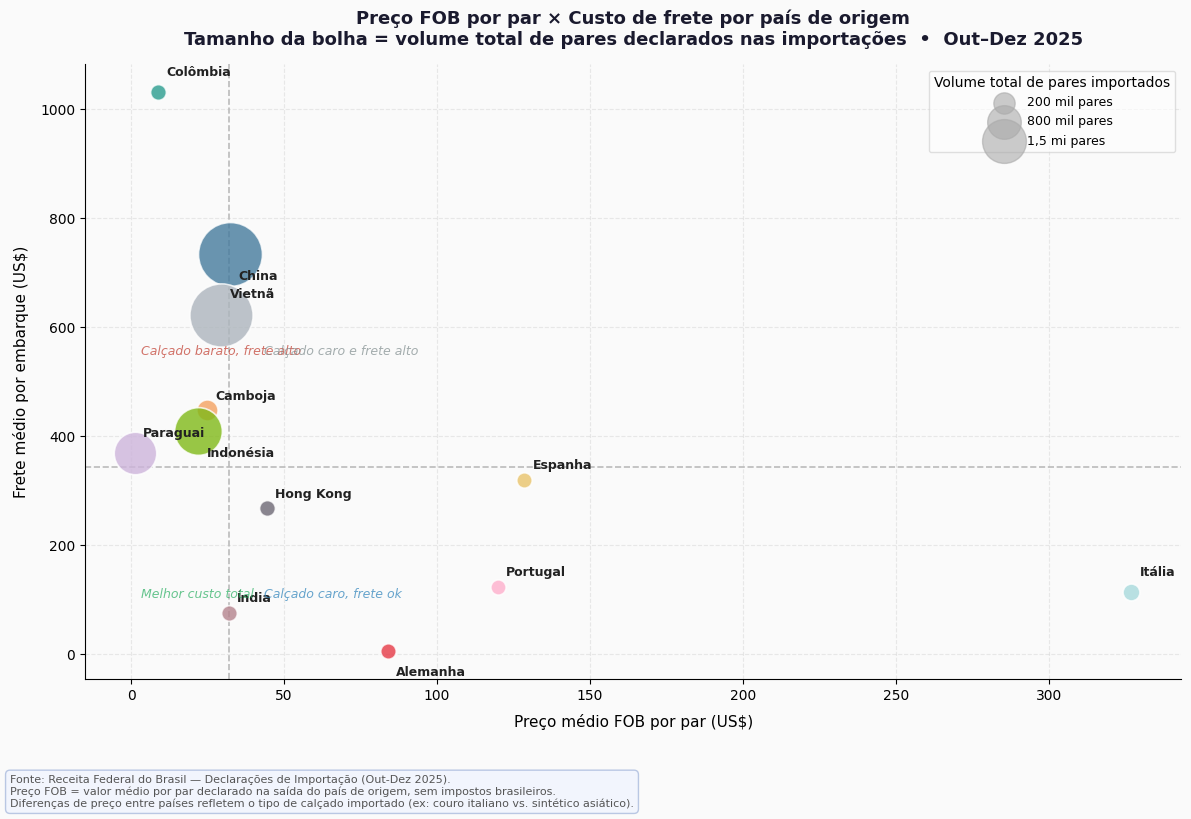

In [5]:
fig3, ax3 = plt.subplots(figsize=(12, 7.5))
fig3.patch.set_facecolor('#FAFAFA')
ax3.set_facecolor('#FAFAFA')

volumes = by_country['volume_total']
sizes   = ((volumes - volumes.min()) / (volumes.max() - volumes.min()) * 2000 + 120)

for i, row in by_country.iterrows():
    ax3.scatter(row['preco_medio'], row['frete_medio'],
                s=sizes.iloc[i], color=PALETA[i % len(PALETA)],
                alpha=0.80, edgecolors='white', linewidth=1.2, zorder=3)
    offsets = {
        'Paraguai': (6, 12), 'China':     (6, -18),
        'Vietnã':   (6, 12), 'Indonésia': (6, -18),
        'Colômbia': (6, 12), 'Alemanha':  (6, -18),
        'Itália':   (6, 12),
    }
    ox, oy = offsets.get(row['pais_label'], (6, 8))
    ax3.annotate(row['pais_label'], (row['preco_medio'], row['frete_medio']),
                 xytext=(ox, oy), textcoords='offset points',
                 fontsize=9, color='#222', fontweight='bold')

xm = by_country['preco_medio'].median()
ym = by_country['frete_medio'].median()
ax3.axvline(xm, color='#bbb', linestyle='--', linewidth=1.2)
ax3.axhline(ym, color='#bbb', linestyle='--', linewidth=1.2)

for qx, qy, ql, qc in [
    (xm * 0.10, ym * 1.60, 'Calçado barato, frete alto', '#c0392b'),
    (xm * 1.35, ym * 1.60, 'Calçado caro e frete alto',  '#7f8c8d'),
    (xm * 0.10, ym * 0.30, 'Melhor custo total',         '#27ae60'),
    (xm * 1.35, ym * 0.30, 'Calçado caro, frete ok',     '#2980b9'),
]:
    ax3.text(qx, qy, ql, fontsize=9, color=qc, alpha=0.70, style='italic')

ax3.set_xlabel('Preço médio FOB por par (US$)', labelpad=8)
ax3.set_ylabel('Frete médio por embarque (US$)', labelpad=8)
ax3.set_title(
    'Preço FOB por par × Custo de frete por país de origem\n'
    'Tamanho da bolha = volume total de pares declarados nas importações  •  Out–Dez 2025',
    fontsize=13, fontweight='bold', pad=14, color='#1a1a2e'
)
for vol, lbl in [(200_000, '200 mil pares'), (800_000, '800 mil pares'), (1_500_000, '1,5 mi pares')]:
    s = ((vol - volumes.min()) / (volumes.max() - volumes.min()) * 2000 + 120)
    ax3.scatter([], [], s=s, color='#aaa', alpha=0.6, label=lbl)
ax3.legend(title='Volume total de pares importados', loc='upper right', framealpha=0.6, fontsize=9)

adicionar_nota(fig3)
fig3.tight_layout()
fig3.savefig('analyses/g3_preco_vs_frete_bolhas.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Gráfico 4 — Quais países enviam mais calçados ao Brasil?

Ranking simples de volume total de pares importados por país. Evidencia quais origens dominam o mercado brasileiro de calçados importados.

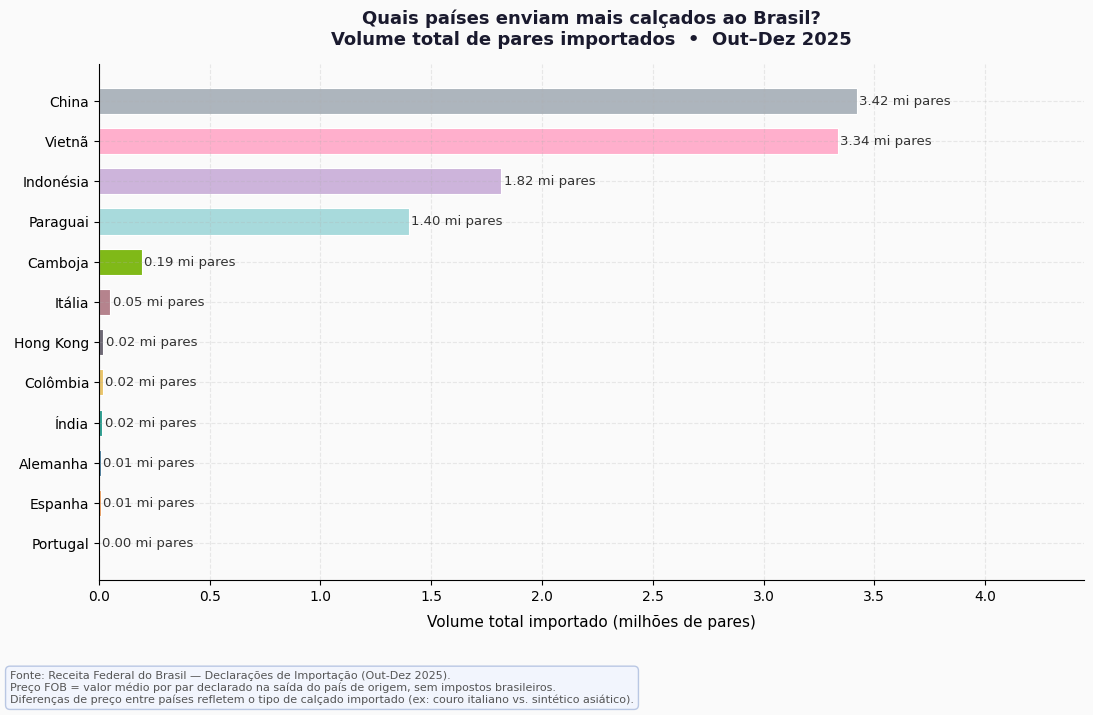

In [6]:
df4 = by_country.sort_values('volume_total', ascending=True).reset_index(drop=True)

fig4, ax4 = plt.subplots(figsize=(11, 6.5))
fig4.patch.set_facecolor('#FAFAFA')
ax4.set_facecolor('#FAFAFA')

bars4 = ax4.barh(df4['pais_label'], df4['volume_total'] / 1_000_000,
                 color=PALETA[:len(df4)], edgecolor='white', linewidth=0.8, height=0.65)

for bar, val in zip(bars4, df4['volume_total']):
    ax4.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val / 1_000_000:.2f} mi pares', va='center', ha='left', fontsize=9.5, color='#333')

ax4.set_xlabel('Volume total importado (milhões de pares)', labelpad=8)
ax4.set_xlim(0, df4['volume_total'].max() / 1_000_000 * 1.30)
ax4.set_title(
    'Quais países enviam mais calçados ao Brasil?\n'
    'Volume total de pares importados  •  Out–Dez 2025',
    fontsize=13, fontweight='bold', pad=14, color='#1a1a2e'
)
adicionar_nota(fig4)
fig4.tight_layout()
fig4.savefig('analyses/g4_volume_por_pais.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ Conclusões

- **Paraguai e China** lideram em preço FOB mais baixo, enquanto **Itália** representa o segmento premium
- **Vietnã e Colômbia** se destacam com fretes elevados em relação ao preço do produto
- **Vietnã, China e Indonésia** dominam o volume importado — são os principais fornecedores do mercado popular brasileiro
- O cenário reforça que calçados de baixo custo no Brasil têm origem predominantemente asiática